# Part II - Exploratory Analysis of US Flights On-Time Performance & Delay Causes (2000-2020)
## by Soizic Bourgeois

## Investigation Overview

When flying delays can be a major frustration. Based on the Carrier On-Time Performance Dataset from Bureau of Transportation, we analysed the frequency of these delays and their main causes on the first 20 years of 21st century flights.


## Dataset Overview and Executive Summary

This document explores a dataset from Bureau of Transportation containing 2,000,000 flights in the United States, including carriers, arrival and departure delays, and reasons for delays from 1987 to 2020.

- Flight arrival and departure delays follow a heavy-right tailed empirical distribution, where most flights arrive early or on time, but a small subset experiences extreme delays.
- The arrival delay is strongly induced by departure delays. The air time does not provide enough buffer to catchup on itnitial delays.
- Hawaiian Airlines and Aloha Air Cargo have less delays than other airline.
- The most impactful root cause of delays is the late aircraft followed by carrier delay.

In [1]:
# import all packages and set plots to be embedded inline
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import lognorm
from sklearn.metrics import r2_score

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

In [2]:
# load in the dataset into a pandas dataframe
# extract files from archive and load csv
with tarfile.open("./data/airline_2m.tar.gz", "r:gz") as t:
    for filename in t.getnames():
        f = t.extractfile(filename)
        flights_df = pd.read_csv(f, low_memory=False, encoding='latin1')

In [3]:
# clean data
flights_df = flights_df[flights_df['Year']>=2000]
flights_df = flights_df[(flights_df['DepDelay'] > -60) & (flights_df['ArrDelay'] > -60)].copy()
flights_df['FlightDate'] = flights_df['FlightDate'].astype('datetime64[ns]')

In [4]:
def generate_title_and_axes(title, x_axis, y_axis):
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel(x_axis, fontsize=11)
    plt.ylabel(y_axis, fontsize=11)

In [5]:
def calculate_r2(model, x, y):
    predict = np.poly1d(model)
    return r2_score(y, predict(x))

In [6]:
def categorize_delay(group):
    if group <= 0:
        return 'Early / On-Time (<=0 min)'
    elif group <= 2:
        return 'Minor Delay (1-45 min)'
    elif group <= 5:
        return 'Moderate Delay (46-90 min)'
    else:
        return 'Severe Delay (>90 min)'

In [7]:
# function to convert categories into intervals
def calculate_interval_ticks_labels(min, max, step):
    boundaries = np.arange(min, max, step)
    tick_labels = [f"<{boundaries[0]}"]
    for start, end in zip(boundaries[:-1], boundaries[1:]):
        tick_labels.append(f"[{start}, {end}[")
    tick_labels.append(f">{boundaries[-1]}")
    return tick_labels

## Distribution of Delays

To begin our analysis, let's examine how flight arrival delays are distributed overall

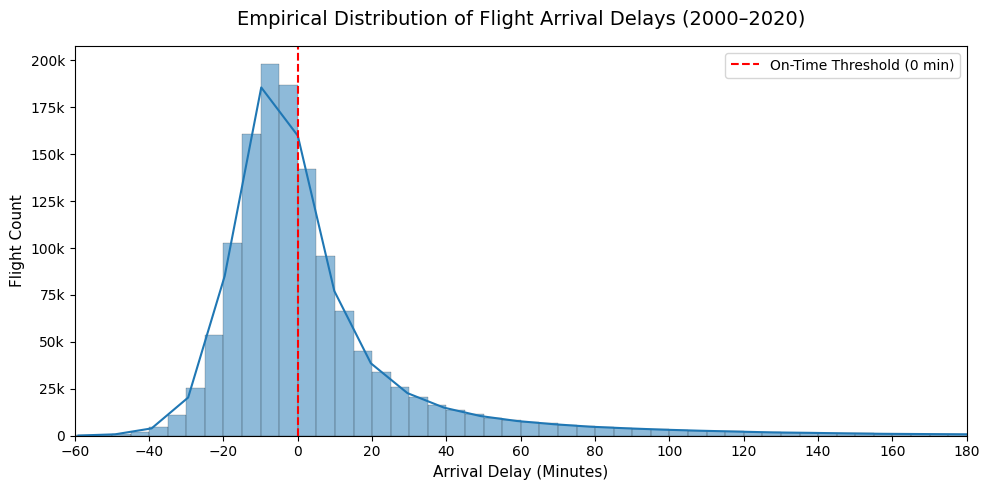

In [8]:
# Set figure size
plt.figure(figsize=(10, 5))

# Plot arrival delay distribution with KDE curve
sns.histplot(
            data=flights_df, 
            x='ArrDelay', 
            kde=True, 
            bins=np.arange(-60, 181, 5), 
            color='tab:blue'
            )

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x*1e-3)}k' if x > 0 else '0'))

# Set focused axis limits to highlight the bulk of the distribution and heavy tail
plt.xlim(-60, 180)
plt.xticks(range(-60, 181, 20))

# Annotate key threshold (on-time boundary)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='On-Time Threshold (0 min)')
plt.legend(loc='upper right')

# Add labels and title
generate_title_and_axes('Empirical Distribution of Flight Arrival Delays (2000–2020)', 'Arrival Delay (Minutes)', 'Flight Count')

plt.tight_layout()
plt.show()

Flight arrival delays follow a strongly right skewed empirical distribution centered around a 10 minutes advance arrival. While most of the flights arrive between 40min in advance and 40min late, the long tail shows the occurence of extreme delays. 

## Departure Delays Pass Directly to Arrival Delays

Now that we've seen how arrival delays are distributed overall, let's look at their causes by first comparing departure delays directly against arrival delays.

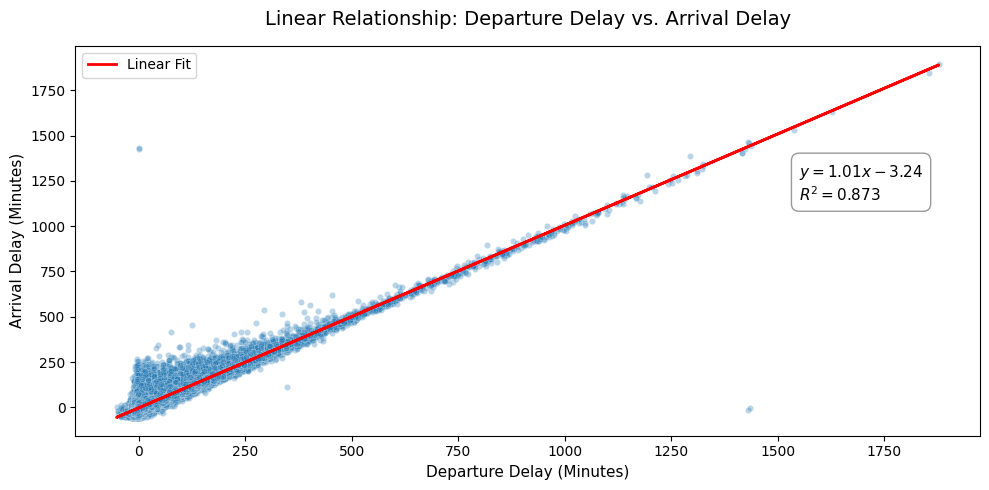

In [9]:
# Set figure size
plt.figure(figsize=(10, 5))

# Scatter plot of departure delay vs arrival delay
sns.scatterplot(
                data=flights_df, 
                x='DepDelay', 
                y='ArrDelay', 
                alpha=0.3, 
                color='tab:blue',
                s=20
                )

# Fit linear regression model on clean data
x_vals = flights_df['DepDelay'].astype(np.float32)
y_vals = flights_df['ArrDelay'].astype(np.float32)
model = np.polyfit(x_vals, y_vals, 1)
r2 = calculate_r2(model, flights_df['DepDelay'], flights_df['ArrDelay'])

# Plot linear regression trendline
plt.plot(
        x_vals, 
        model[0] * x_vals + model[1], 
        color='red', 
        linewidth=2, 
        label=f'Linear Fit'
        )

plt.text(
        0.80, 0.70, 
        f'$y = {model[0]:.2f}x {model[1]:+.2f}$\n$R^2 = {r2:.3f}$', 
        transform=plt.gca().transAxes, 
        fontsize=11, 
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
        )

# Add custom title, labels, legend, and layout
generate_title_and_axes("Linear Relationship: Departure Delay vs. Arrival Delay", "Departure Delay (Minutes)", "Arrival Delay (Minutes)")
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()

plt.show()

**No Airborne Recovery**

With $y = 1.01x - 3.24$ ($R^2 = 0.873$), flights do not make up lost time in the air. Operational interventions must focus 100% on ground turn times.

## Arrival Delays Across Carriers

Now that we've seen how delays propagate from departure to arrival, let's examine whether overall on-time performance varies significantly by airline. 

This chart breaks down the proportion of flight arrival delay categories across each reporting carrier, allowing us to see which airlines maintain a higher share of on-time flights and which are more susceptible to severe delays.

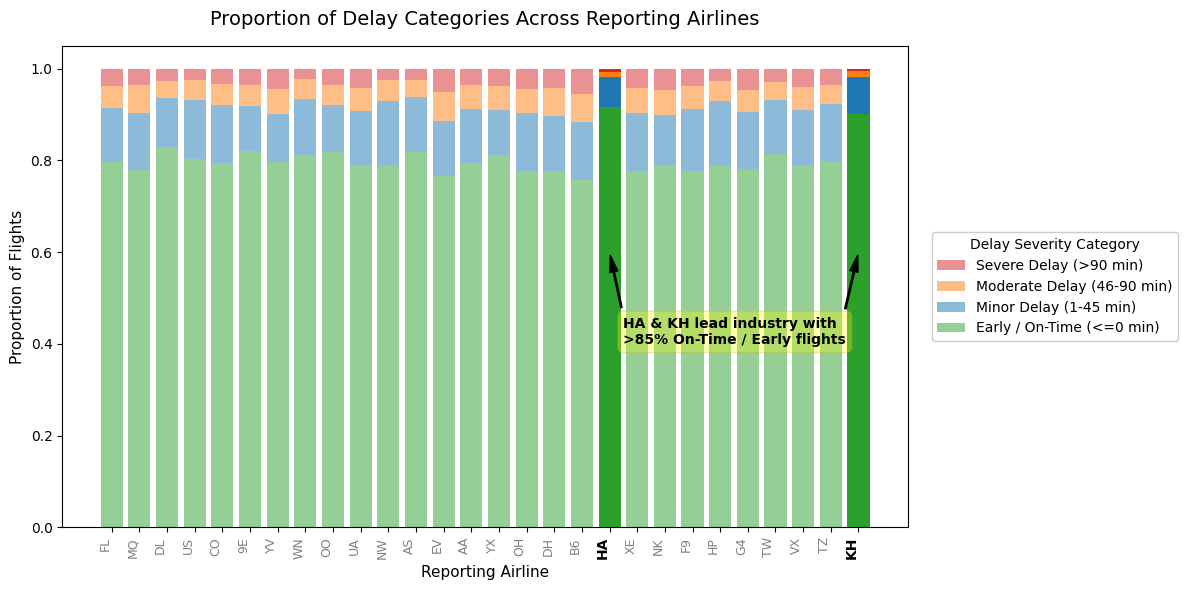

In [10]:
# Create broader operational delay categories
flights_df['DelayCategory'] = flights_df['ArrivalDelayGroups'].apply(categorize_delay)

# Define logical order and custom distinct colors
cat_order = ['Early / On-Time (<=0 min)', 'Minor Delay (1-45 min)', 'Moderate Delay (46-90 min)', 'Severe Delay (>90 min)']
custom_colors = ['tab:green', 'tab:blue', 'tab:orange', 'tab:red']

plt.figure(figsize=(12, 6))
artists = []
airlines = flights_df['Reporting_Airline'].unique()
baselines = np.zeros(len(airlines))
airlines_counts = flights_df['Reporting_Airline'].value_counts()

# Highlight targets
standout_airlines = ['HA', 'KH']

for i, category in enumerate(cat_order):
    inner_counts = flights_df[flights_df['DelayCategory'] == category]['Reporting_Airline'].value_counts()
    inner_props = inner_counts / airlines_counts
    heights = inner_props[airlines].fillna(0).values
    
    bars = plt.bar(
                    x=np.arange(len(airlines)), 
                    height=heights, 
                    bottom=baselines, 
                    color=custom_colors[i], 
                    label=category
                    )
    
    # highlight KH and HA bars
    for idx, bar in enumerate(bars):
        airline_code = airlines[idx]
        if airline_code in standout_airlines:
            bar.set_alpha(1.0)
        else:
            bar.set_alpha(0.5)
            
    artists.append(bars)
    baselines += heights

# Format X-ticks and axis labels
plt.xticks(np.arange(len(airlines)), airlines, rotation=90, ha='right', fontsize=9)

# Bold tick labels for HA and KH
ax = plt.gca()
for label in ax.get_xticklabels():
    if label.get_text() in standout_airlines:
        label.set_weight('bold')
        label.set_color('black')
        label.set_fontsize(10)
    else:
        label.set_color('gray')

# Add Callout Box / Annotation
airlines_list = list(airlines)
ha_idx = airlines_list.index('HA') if 'HA' in airlines_list else 0
kh_idx = airlines_list.index('KH') if 'KH' in airlines_list else len(airlines_list) - 1

text_x = ha_idx +0.5
text_y = 0.40 

plt.annotate(
            'HA & KH lead industry with\n>85% On-Time / Early flights',
            xy=(ha_idx, 0.6),
            xytext=(text_x, text_y),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontsize=10, 
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.4", facecolor="yellow", alpha=0.3, edgecolor="goldenrod")
            )

plt.annotate(
            '',
            xy=(kh_idx, 0.6),
            xytext=(text_x + 8, text_y+0.07),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6)
            )

# Legend
plt.legend(
            reversed(artists), 
            reversed(cat_order), 
            title='Delay Severity Category', 
            bbox_to_anchor=(1.02, 0.5), 
            loc='center left', 
            framealpha=1
            )

generate_title_and_axes(
                        "Proportion of Delay Categories Across Reporting Airlines", 
                        "Reporting Airline", 
                        "Proportion of Flights"
                        )

plt.tight_layout()
plt.show()

**Best Performing Airlines**

Hawaiian Airlines (HA) and Aloha Air Cargo (KH)have more than 85% of their flights on-time which proves that tight regional scheduling and turnaround discipline significantly mitigate delay propagation.

## Frequency of Delay Causes Across Arrival Delay Severity Groups

Now that we’ve seen how delay proportions vary across airlines, let's dive into the specific root causes driving these delays across different levels of severity.

This graph breaks down the frequency of carrier, weather, NAS, security, and late aircraft delays across each 15-minute arrival delay interval.

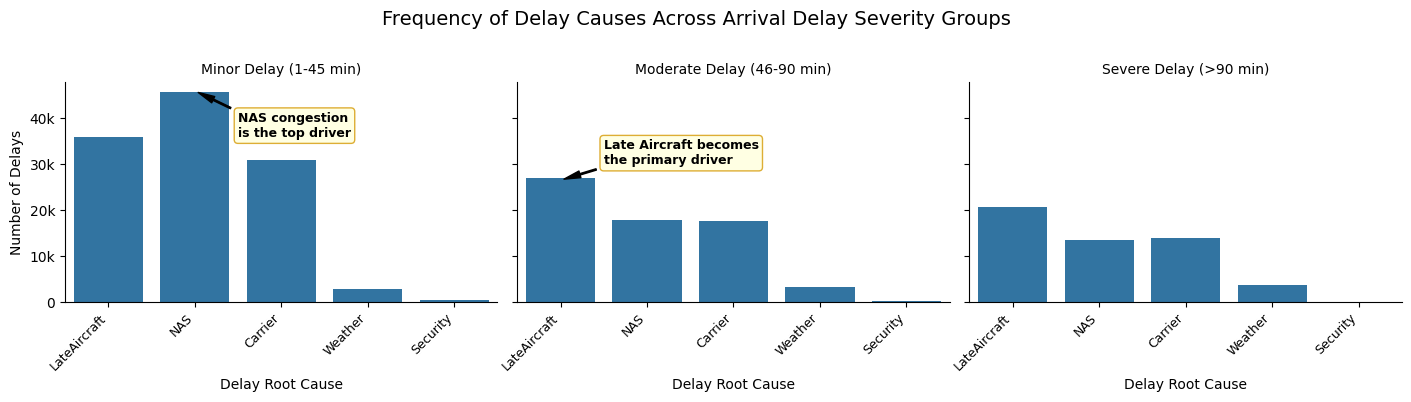

In [11]:
# generate new DelayType column
delay_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

df_delays = flights_df[['ArrivalDelayGroups'] + delay_cols].melt(
                                                                id_vars=['ArrivalDelayGroups'],
                                                                value_vars=delay_cols,
                                                                var_name='DelayType',
                                                                value_name='DelayMinutes'
                                                                )

# keep only delays greater than 15min
df_delays = df_delays[df_delays['DelayMinutes'] >= 15].copy()
df_delays['DelayType'] = df_delays['DelayType'].str.replace('Delay', '')

# calculate the delay intervals
interval_labels = calculate_interval_ticks_labels(-30, (df_delays['ArrivalDelayGroups'].max()+1)*15, 15)
df_delays['DelayInterval'] = df_delays['ArrivalDelayGroups'].apply(lambda g: interval_labels[int(g) + 2] if -2 <= g <= 12 else str(g))

# Group into 4 high-level categories for presentation clarity
df_delays['DelayCategory'] = df_delays['ArrivalDelayGroups'].apply(categorize_delay)

g = sns.FacetGrid(
                    data=df_delays, 
                    col='DelayCategory', 
                    col_order=['Minor Delay (1-45 min)', 'Moderate Delay (46-90 min)', 'Severe Delay (>90 min)'],
                    col_wrap=3, 
                    height=4, 
                    aspect=1.2
                    )

delay_order = df_delays['DelayType'].value_counts().index
g.map_dataframe(sns.countplot, x='DelayType', order=delay_order)

# format ticks
formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x*1e-3)}k' if x > 0 else '0')
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(formatter)
g.set_xticklabels(labels=delay_order, rotation=45, ha='right', fontsize=9)

# add annotation
ax_minor = g.axes[0]
ax_minor.annotate(
                    "NAS congestion\nis the top driver",
                    xy=(1, 46000),
                    xytext=(1.5, 36000),
                    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=5),
                    fontsize=9,
                    fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="goldenrod", alpha=0.9)
                    )


ax_medium = g.axes[1]
ax_medium.annotate(
                    "Late Aircraft becomes\nthe primary driver",
                    xy=(0, 26500),
                    xytext=(0.5, 30000),
                    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=5),
                    fontsize=9,
                    fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="goldenrod", alpha=0.9)
                    )

# Format titles and axes
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Delay Root Cause", "Number of Delays")

plt.subplots_adjust(hspace=0.5, bottom=0.25, top=0.8)
g.fig.suptitle("Frequency of Delay Causes Across Arrival Delay Severity Groups", fontsize=14, y=0.98)

plt.show()

**Late Aircraft** 

NAS congestion causes minor delays (1-45 min), but late aircraft dominate medium and severe delays.

## Late Aircraft & Carrier Issues Account for more than 70% of Total Delay Duration

We have looked at the frequency of each cause in the previous graph, now let's look at the time impact of each of them.

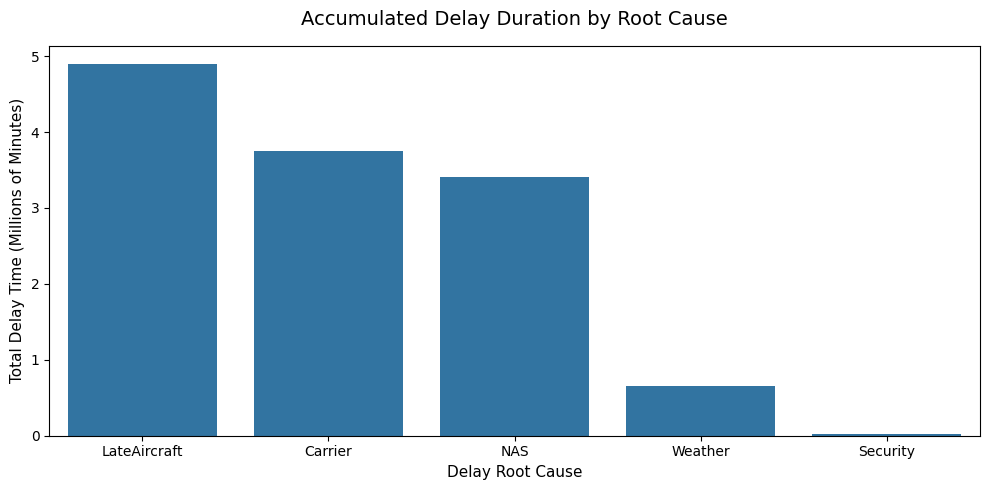

In [12]:
# calculate total sum of delay minutes for each root cause
delay_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
total_minutes = flights_df[delay_cols].sum().reset_index()
total_minutes.columns = ['DelayType', 'TotalMinutes']
total_minutes['TotalMillions'] = total_minutes['TotalMinutes'] / 1e6

# clean up names and sort by total duration
total_minutes['DelayType'] = total_minutes['DelayType'].str.replace('Delay', '')
total_minutes = total_minutes.sort_values(by='TotalMillions', ascending=False)

# set figure size
plt.figure(figsize=(10, 5))

# plot
sns.barplot(
            data=total_minutes, 
            x='DelayType', 
            y='TotalMillions'
            )

# title and axes
generate_title_and_axes(
                        "Accumulated Delay Duration by Root Cause", 
                        "Delay Root Cause", 
                        "Total Delay Time (Millions of Minutes)"
                        )

plt.xticks(fontsize=10)
plt.tight_layout()

plt.show()

**Focus for Mitigation**

Reactional Late Aircraft delays waste nearly 5 million minutes annually. Operational improvement by the carriers hold the highest ROI for delay reduction.